# Analyzing Lung Sounds Datasets

In [ ]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

from matplotlib import pyplot as plt

from modules.dataset import ICBHIDataset, FraiwanDataset, CombinedLungSoundDataset, LungSoundDataset

ALL_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    "Bronchitis",
    "COPD",
    "Healthy",
    "Heart Failure",
    "LRTI",
    "Lung Fibrosis",
    "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), "data")
if not os.path.exists(data_path):
    print(f"Data directory not found at {data_path}. Please ensure the data is downloaded and placed in the correct location.")

## Datasets Distributions

### ICBHI 2017

In [3]:
icbhi_dataset = ICBHIDataset(data_path, "all", classes=ALL_CLASSES)
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head(10)

Dataset size: 920 samples


,Source,FilePath,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,AudioDuration,Label
0,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,20.000,7
1,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,20.000,7
2,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,20.000,4
3,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,70.00,F,33.00,NaN,NaN,I103,2b2,Ar,mc,LittC2SE,20.000,0
4,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Al,sc,Litt3200,15.856,3
5,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ar,sc,Litt3200,25.584,3
6,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ll,sc,Litt3200,18.480,3
7,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Lr,sc,Litt3200,15.024,3
8,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pl,sc,Litt3200,22.960,3
9,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pr,sc,Litt3200,23.728,3


#### Unit Test

Sample 0:
  File name: 101_1b1_Al_sc_Meditron.wav
  Label: 7 (URTI)
  Sample rate: 44100
  Audio shape: (882000,)


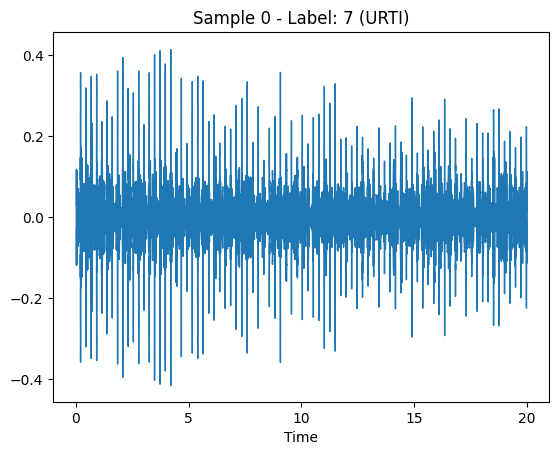

In [4]:
icbhi_dataset.unit_test(idx=0)

#### Class Distribution

In [5]:
def plot_label_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of labels in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset containing label information.
    """
    data = dataset.data
    label_counts = data["Diagnosis"].value_counts()
    display(label_counts)
    label_counts.plot(kind="bar")
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

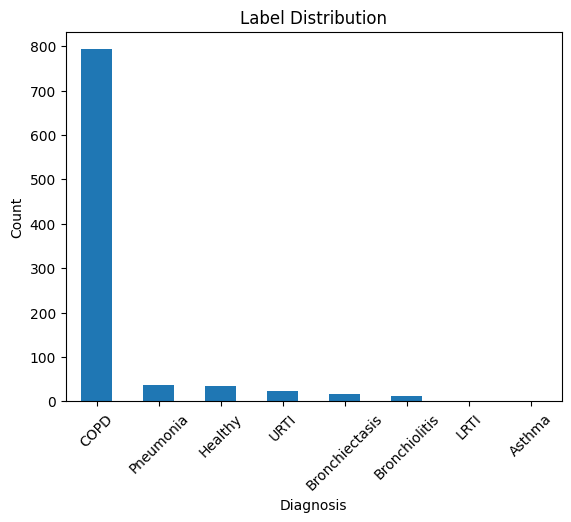

In [6]:
plot_label_distribution(icbhi_dataset)

#### Demographics

In [7]:
def plot_demographic_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of demographic features in the dataset (Age and Sex).
    Args:
        dataset (LungSoundDataset): The dataset containing demographic information.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    data = dataset.data
    
    # Age distribution
    data["Age"].plot(kind="hist", bins=100, ax=axes[0], color="skyblue")
    axes[0].set_title("Age Distribution")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Count")

    # Sex distribution
    data["Sex"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
    axes[1].set_title("Sex Distribution")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Count")

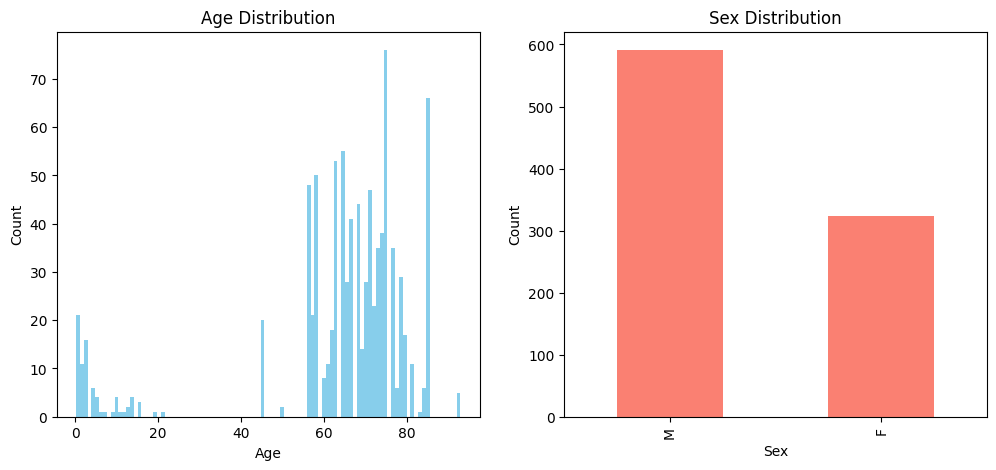

In [8]:
plot_demographic_distribution(icbhi_dataset)

#### Duration

In [9]:
# Iterate over the dataset to get the distriqution of the duration of the recordings
def plot_recording_duration_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of recording durations in the dataset.
    Args:
        data (pd.DataFrame): The dataset containing recording duration information.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    dataset.data["AudioDuration"].plot(kind="hist", bins=50, ax=ax)
    ax.set_title("Recording Duration Distribution")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    plt.show()

    # For each label, plot the distribution
    num_classes = len(dataset.classes)
    num_rows = (num_classes + 1) // 2
    num_cols = 2 if num_classes > 1 else 1
    fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 4))
    ax = ax.flatten() if num_classes > 1 else [ax]
    if num_classes == 1:
        ax = [ax]
    for i, diagnosis in enumerate(dataset.classes):
        subset = dataset.data[dataset.data["Diagnosis"] == diagnosis]
        subset["AudioDuration"].plot(kind="hist", bins=50, ax=ax[i], alpha=0.5, label=diagnosis)
        ax[i].set_title(f"{diagnosis}")
        ax[i].set_xlabel("Duration (seconds)")
        ax[i].set_ylabel("Count")
        ax[i].legend()
    plt.tight_layout()
    plt.show()

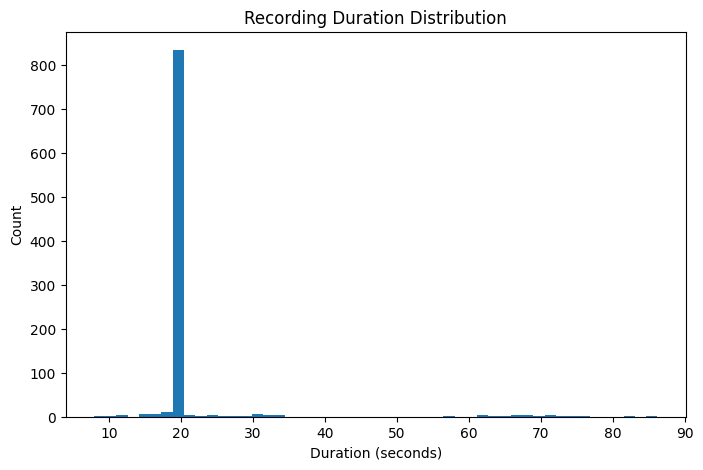

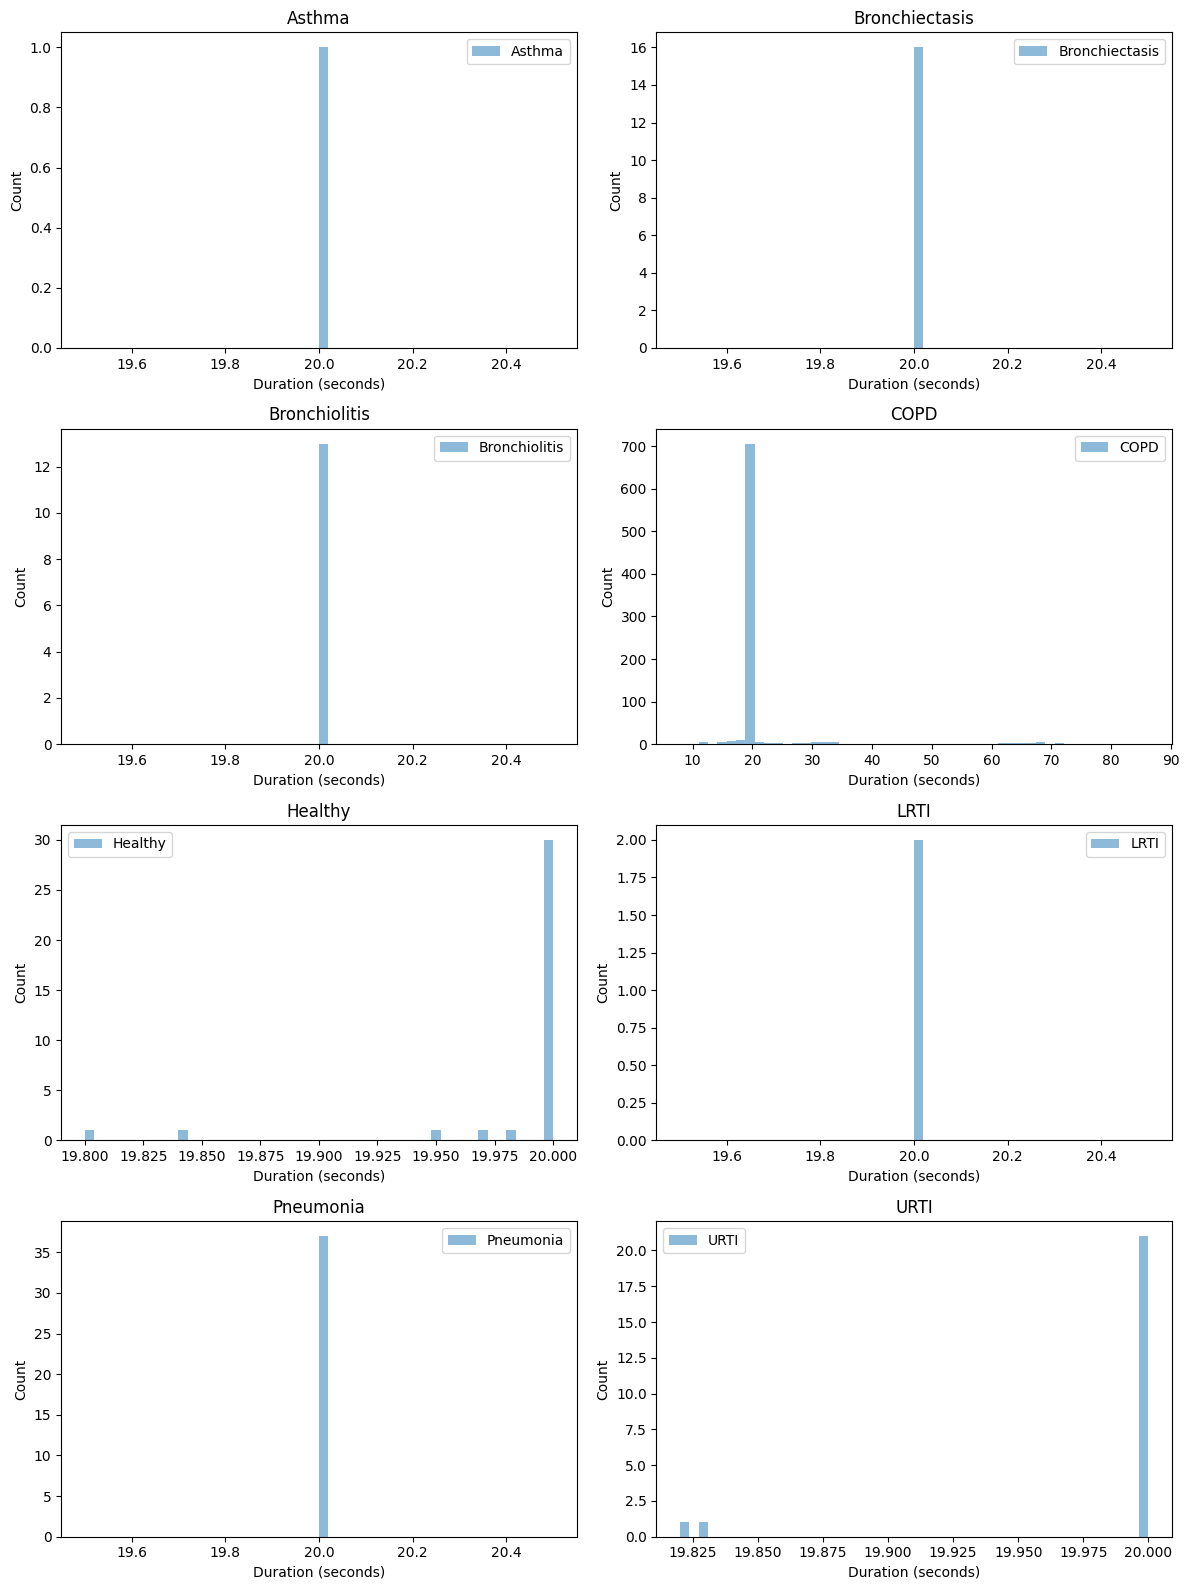

In [10]:
plot_recording_duration_distribution(icbhi_dataset)

### Fraiwan et. al. 2021

In [11]:
fraiwan_dataset = FraiwanDataset(data_path, "all", classes=ALL_CLASSES)
print(f"Dataset size: {len(fraiwan_dataset)} samples")
fraiwan_dataset.data.head(10)

Dataset size: 324 samples


,Source,FilePath,Diagnosis,FilterCode,PatientId,Sound type,Location,Age,Sex,AudioDuration,Label
0,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P100,N,P R M,70.0,F,13.552,3
1,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P101,E W,P L M,12.0,F,13.552,0
2,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P102,N,P L L,41.0,M,19.056,3
3,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P103,N,P R U,81.0,F,12.848,3
4,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P104,E W,P L U,45.0,F,11.760,0
5,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Lung Fibrosis,B,P105,Crep,A U R,44.0,M,25.264,5
6,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P106,E W,P L U,45.0,F,19.824,0
7,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P107,E W,P L U,59.0,F,12.656,0
8,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,B,P108,E W,P R L,63.0,M,22.832,2
9,fraiwan,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P109,N,P L M,26.0,M,13.232,3


#### Unit Test

Sample 0:
  File name: BP100_N,N,P R M,70,F.wav
  Label: 3 (Healthy)
  Sample rate: 4000
  Audio shape: (54208,)


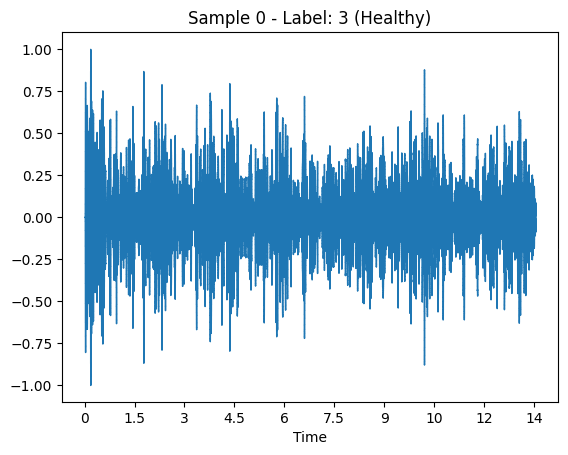

In [12]:
fraiwan_dataset.unit_test(idx=0)

#### Class Distribution

Diagnosis
Healthy             105
Asthma               96
Heart Failure        54
COPD                 27
Pneumonia            15
Lung Fibrosis        12
Bronchitis            9
Pleural Effusion      6
Name: count, dtype: int64

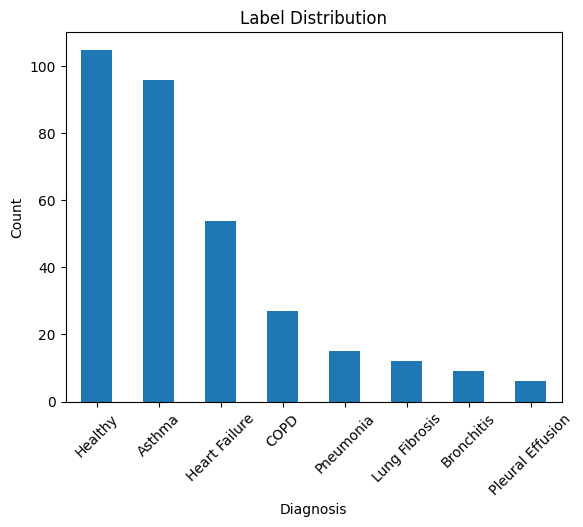

In [13]:
plot_label_distribution(fraiwan_dataset)

#### Demographics

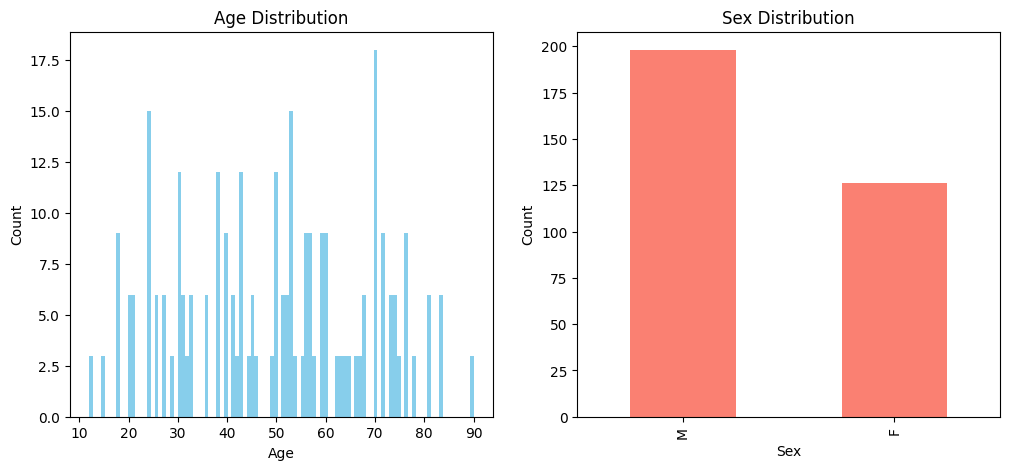

In [14]:
plot_demographic_distribution(fraiwan_dataset)

#### Duration

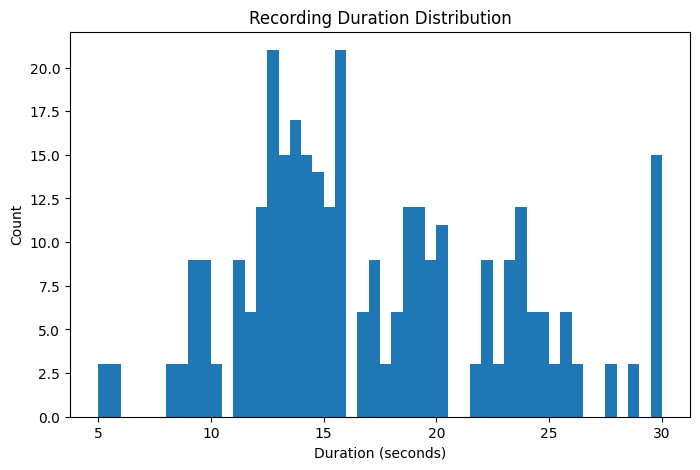

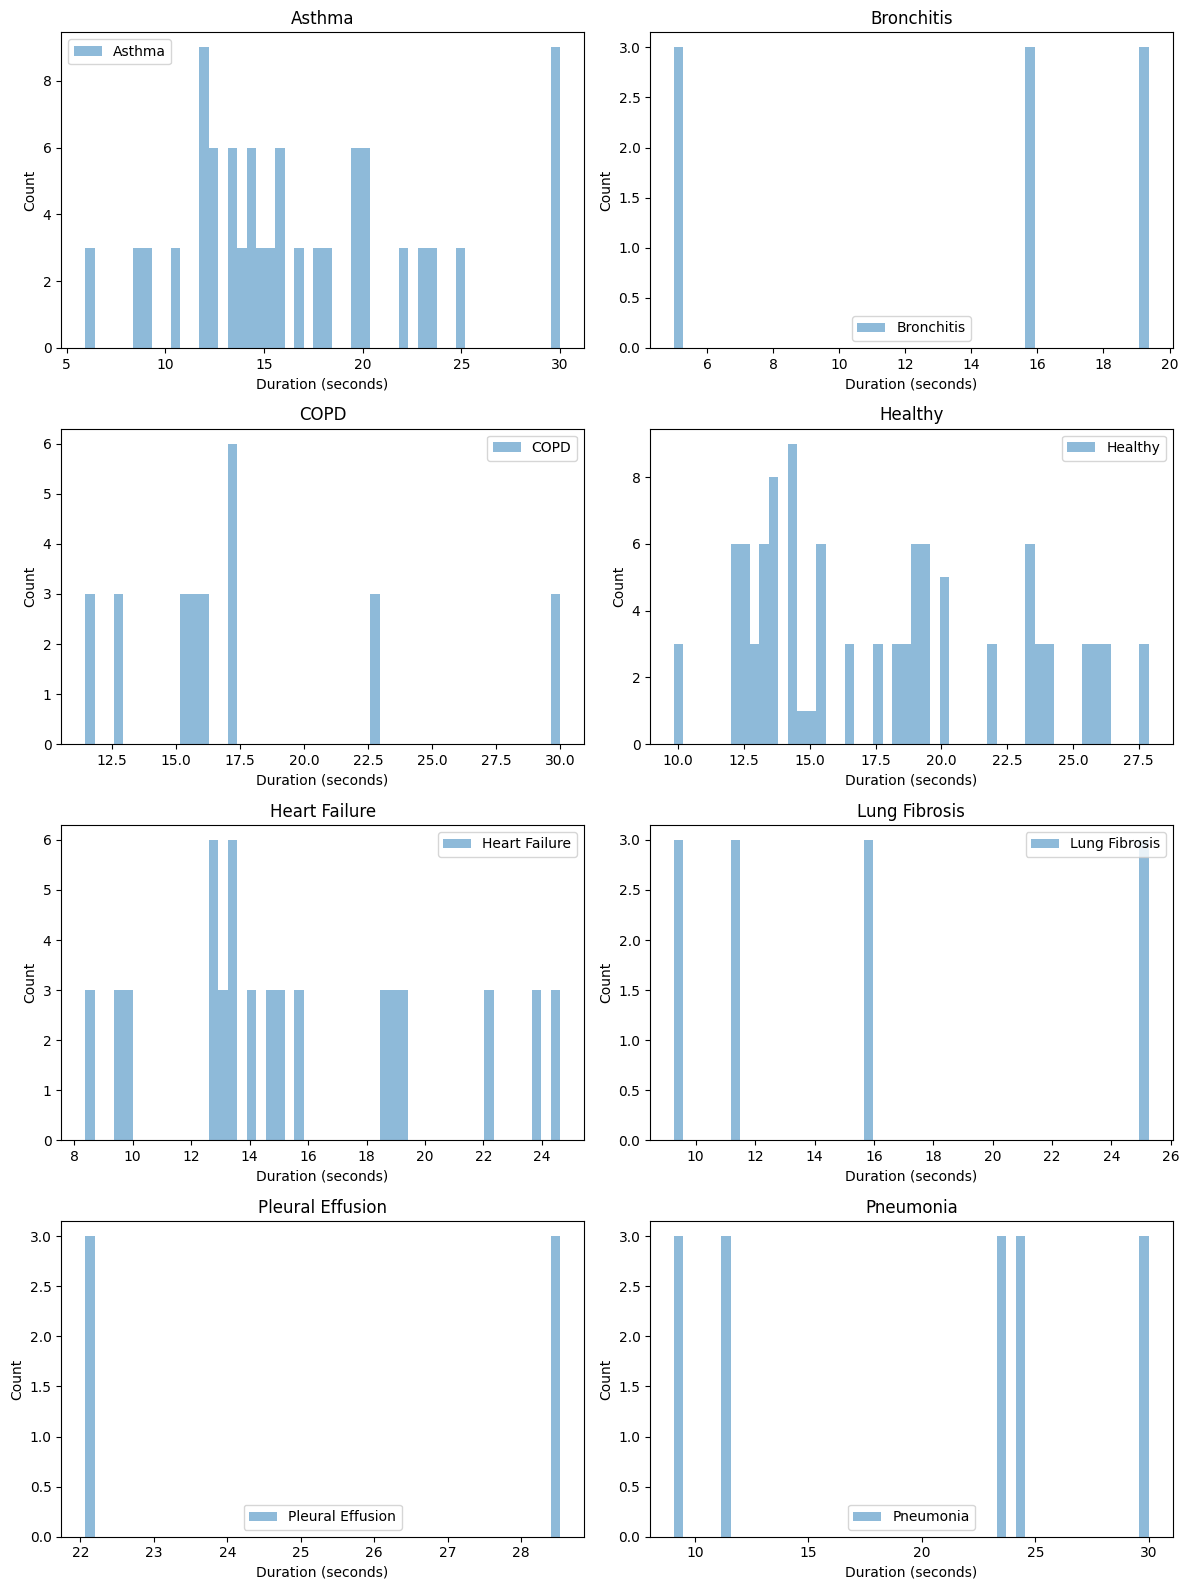

In [15]:
plot_recording_duration_distribution(fraiwan_dataset)

### Combined Datasets

In [16]:
combined_dataset = CombinedLungSoundDataset(data_path, "all", classes=ALL_CLASSES)
print(f"Dataset size: {len(combined_dataset)} samples")
combined_dataset.data.head(10)

Dataset size: 1244 samples


,Source,FilePath,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,AudioDuration,FilterCode,Sound type,Location,Label
0,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,20.000,NaN,NaN,NaN,11
1,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,20.000,NaN,NaN,NaN,11
2,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,20.000,NaN,NaN,NaN,5
3,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,70.00,F,33.00,NaN,NaN,I103,2b2,Ar,mc,LittC2SE,20.000,NaN,NaN,NaN,0
4,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Al,sc,Litt3200,15.856,NaN,NaN,NaN,4
5,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ar,sc,Litt3200,25.584,NaN,NaN,NaN,4
6,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ll,sc,Litt3200,18.480,NaN,NaN,NaN,4
7,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Lr,sc,Litt3200,15.024,NaN,NaN,NaN,4
8,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pl,sc,Litt3200,22.960,NaN,NaN,NaN,4
9,icbhi,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pr,sc,Litt3200,23.728,NaN,NaN,NaN,4


#### Unit Test

Sample 0:
  File name: 101_1b1_Al_sc_Meditron.wav
  Label: 11 (URTI)
  Sample rate: 44100
  Audio shape: (882000,)


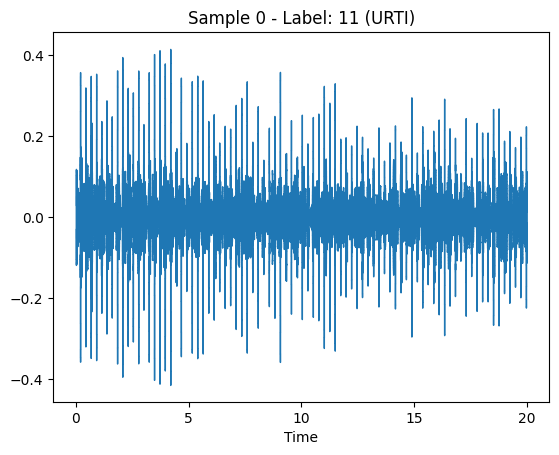

In [17]:
combined_dataset.unit_test(idx=0)

#### Class Distribution

Diagnosis
COPD                820
Healthy             140
Asthma               97
Heart Failure        54
Pneumonia            52
URTI                 23
Bronchiectasis       16
Bronchiolitis        13
Lung Fibrosis        12
Bronchitis            9
Pleural Effusion      6
LRTI                  2
dtype: int64

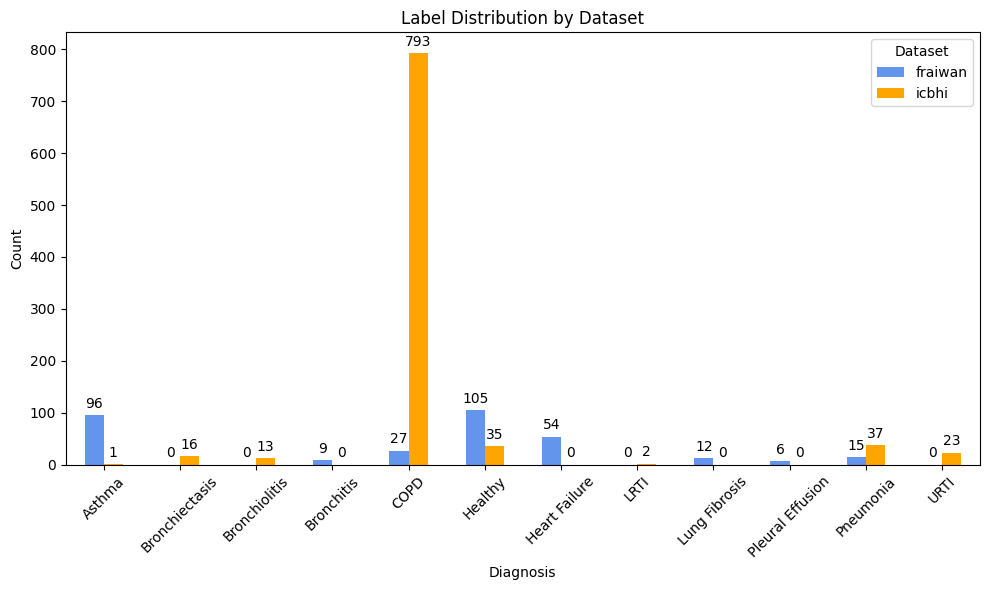

In [18]:
counts_df = (
    combined_dataset.data
    .groupby(["Diagnosis", "Source"])
    .size()
    .unstack(fill_value=0)
)
label_counts = counts_df.sum(axis=1).sort_values(ascending=False)
display(label_counts)

colors = ["cornflowerblue", "orange"]
ax = counts_df.plot(kind="bar", figsize=(10, 6), color=colors)
ax.set_title("Label Distribution by Dataset")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Dataset")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()